In [1]:
import json
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.special import stirling2
import math
from copy import copy

In [2]:
status_codes = {
    1: 'LOADED',
    2: 'OPTIMAL',
    3: 'INFEASIBLE',
    4: 'INF_OR_UNBD',
    5: 'UNBOUNDED',
    6: 'CUTOFF',
    7: 'ITERATION_LIMIT',
    8: 'NODE_LIMIT',
    9: 'TIME_LIMIT',
    10: 'SOLUTION_LIMIT',
    11: 'INTERRUPTED',
    12: 'NUMERIC',
    13: 'SUBOPTIMAL',
    14: 'INPROGRESS',
    15: 'USER_OBJ_LIMIT'
}

In [3]:
rng = np.random.default_rng(965)

# SDP Minimal Working Example

# Multivariate utils

In [4]:
def compute_order(alpha):
    '''Sum of elements of a power.'''
    order = 0
    for alpha_i in alpha:
        order += alpha_i
    return order

def compute_Nd(S, d):
    '''Number of moments of order <= d (S species)'''
    Nd = math.factorial(S + d) // (math.factorial(d) * math.factorial(S))
    return Nd

def compute_powers(S, d):
    '''Compute the Nd powers of order <= d (S species)'''

    # all powers
    powers = [[0 for s in range(S)]]

    # powers of order d = 0
    powers_prev = [[0 for s in range(S)]]

    # for order d = 1, ..., d
    for order in range(1, d + 1):

        # store powers of order d
        powers_current = []

        # for each power of order d - 1
        for alpha in powers_prev:

            # for each index
            for i in range(S):

                # add 1 to power at index
                alpha_new = copy(alpha)
                alpha_new[i] += 1

                # store (avoid repeats)
                if alpha_new not in powers_current:
                    powers_current.append(alpha_new)

        # update d - 1 powers
        powers += powers_current

        # update overall powers
        powers_prev = powers_current

    return powers

def add_powers(*powers, S):
    '''Add powers (lists) of size S.'''
    plus = [0 for i in range(S)]
    for i in range(S):
        for power in powers:
            plus[i] += power[i]
    return plus

def falling_factorial(n, k):
    '''FF(n,k) = n(n-1) ... (n - k + 1).'''
    val = 1
    for i in range(k):
        val *= (n - i)
    return val

def binomial_moment(n, p, l):
    '''For X ~ Bin(n, p) compute E[X^l].'''
    val = 0
    for k in range(l + 1):
        val += falling_factorial(n, k) * stirling2(l, k) * p**k
    return val

# Simulation

In [5]:
def coeff(xs, vsr):
    br = math.factorial(xs) / math.factorial(xs - vsr)
    return br

In [6]:
def gillespie(stoch_inp, stoch_out, rates, tmax):

    # size
    R, S = stoch_inp.shape

    # reaction changes
    stoch = stoch_out - stoch_inp

    # initialization
    t = 0
    x = np.zeros(S)
    path = [x]
    path_times = [0]

    # convert to int
    x = x.astype(np.int64)
    stoch = stoch.astype(np.int64)
    stoch_inp = stoch_inp.astype(np.int64)

    # simulate for burn in and intervals between samples
    while t < tmax:

        # compute reaction propensities ----------------------------------------
        props = np.zeros(R)

        # for each reaction
        for r in range(R):

            # inital rate
            ar = rates[r]

            # for each species
            for s in range(S):
                
                # not involved
                if stoch_inp[r, s] == 0:
                    continue

                # not enough
                if x[s] < stoch_inp[r, s]:
                    ar = 0
                    continue

                # otherwise: multiply rate component
                ar *= coeff(x[s], stoch_inp[r, s])

            # set propensity
            props[r] = ar

        # overall propensity
        a0 = np.sum(props)

        # holding time ---------------------------------------------------------
        t_hold = -np.log(rng.uniform()) / a0
        t += t_hold
        path_times.append(t)

        # next reaction --------------------------------------------------------
        r = rng.choice(range(R), p=props / a0)
        x += stoch[r, :]
        path.append(list(x))

    # convert to array
    path = np.array(path)
    path_times = np.array(path_times)

    return path, path_times

In [7]:
def uniform_time_samples(path, path_times, tmin, tint):

    # size
    _, S = path.shape

    # take n samples at regular intervals after burn in
    n = (tmax - tmin) // tint
    print(f"Taking {n} uniform time samples")

    # store
    sampled_path = np.zeros((n, S))

    # for each time find state of step function
    t_sample = tmin
    for i in range(n):
        mask = (path_times < t_sample)
        sampled_path[i, :] = path[mask, :][-1, :]
        t_sample += tint

    return sampled_path

# Bootstrap

In [36]:
def bootstrap(sample, d, resamples=1000):
    '''
    Compute confidence intervals on the moments of a sample of count pairs, use
    resamples number of bootstrap resamples (default to sample size) and estimate
    moments up to order d.

    Args:
        sample: cell x observed species (n x SO) array of integer counts
        d: maximum moment order to estimate
        resamples: integer number of bootstrap resamples to use

    Returns:
        (2 x Nd) numpy array of CI bounds on each Nd moment of order <= d
    '''

    # size
    n, SO = sample.shape 

    # helpful values
    powers = compute_powers(S=SO, d=d)
    Nd = compute_Nd(S=SO, d=d)

    # bootstrap to N x n x SO array
    boot = rng.choice(sample, size=(resamples, n))

    # split into 2 N x n arrays
    x1_boot = boot[:, :, 0]
    x2_boot = boot[:, :, 1]

    # estimate
    moment_bounds = np.zeros((2, Nd))
    for i, alpha in enumerate(powers):

        # compute x1**alpha1 * ... * xSO**alphaSO over bootstrap
        boot_alpha = 1

        # for each species
        for j, alpha_j in enumerate(alpha):

            # raise to power
            xj_boot_alpha = boot[:, :, j]**alpha[j]

            # multiply
            boot_alpha *= xj_boot_alpha

        # mean over sample axis (N x n) -> (N x 1)
        moment_estimates = np.mean(boot_alpha, axis=1)

        # quantile over boot axis (N x 1) -> (2 x 1)
        moment_interval = np.quantile(moment_estimates, [0.025, 0.975])

        # store
        moment_bounds[:, i] = moment_interval

    return moment_bounds

# Downsampling

In [47]:
def downsample_data(sample, mean_capture):

    # size
    n, _ = sample.shape

    # parameters
    b = (1 / mean_capture) - 1

    # capture efficiency
    if b == 0:
        beta = np.ones(n)
    else:
        beta = rng.beta(1, b, size=n)
    
    # downsample
    downsample = rng.binomial(sample.astype(np.int64), beta[:, None])

    return downsample, beta

# Moment equations

In [38]:
def compute_A(alpha, reactions, vrs, db, R, S, d):
    '''
    Moment equation coefficient matrix
    NOTE: must have order of alpha <= d

    Args:
        alpha: moment order for equation (d/dt mu^alpha = 0)
        reactions: list of strings detailing a_r(x) for each reaction r
        vrs: list of lists detailing v_r for each reaction r
        db: largest order a_r(x)
        R: number of reactions
        S: number of species
        d: maximum moment order used (must be >= order(alpha) + db - 1)

    Returns:
        A: (R, Nd) matrix of coefficients
    '''

    if compute_order(alpha) > d - db + 1:
        raise NotImplementedError(f"Maximum moment order {d} too small for moment equation of alpha = {alpha}: involves moments of higher order.")

    xs = sp.symbols([f'x{i}' for i in range(S)])

    # reaction propensity polynomials
    # props = [eval(str_ar) for str_ar in reactions]
    props = [sp.parse_expr(str_ar, {'xs': xs}) for str_ar in reactions]

    # number of moments of order <= d
    Nd = compute_Nd(S, d)

    # get powers of order <= d
    powers = compute_powers(S, d)

    # setup matrix
    A = np.zeros((R, Nd))

    for r, prop in enumerate(props):

        # expand b(x) * ((x + v_r)**alpha - x**alpha)
        term_1 = 1
        term_2 = 1
        for i in range(S):
            term_1 = term_1 * (xs[i] + vrs[r][i])**alpha[i]
            term_2 = term_2 * xs[i]**alpha[i]
        poly = sp.Poly(prop * (term_1 - term_2), xs)

        # loop over terms
        for xs_power, coeff in zip(poly.monoms(), poly.coeffs()):

            # get matrix index
            col = powers.index(list(xs_power))

            # store
            A[r, col] = coeff

    return A

# B Capture matrix

In [39]:
def compute_B(beta, S, U, d):
    '''
    Capture efficiency moment scaling matrix

    Args:
        beta: per cell capture efficiency sample
        S: number of species
        U: unobserved species indices
        d: maximum moment order used

    Returns:
        B: (Nd, Nd) matrix of coefficients
    '''

    # number of moments of order <= d
    Nd = compute_Nd(S, d)

    # compute powers of order <= d
    powers = compute_powers(S, d)

    # compute beta moments of order <= d
    y_beta = np.zeros(d + 1)
    for l in range(d + 1):
        y_beta[l] = np.mean(beta**l)

    # setup matrix
    B = np.zeros((Nd, Nd))

    p = sp.Symbol('p')
    xs = sp.symbols([f'x{i}' for i in range(S)])

    # for each moment power
    for row, alpha in enumerate(powers):

        # setup polynomail
        poly_alpha = 1

        # for each species
        for i in range(S):

            # unobserved: no capture efficiency
            if i in U:
                moment = xs[i]**alpha[i]

            # observed: compute moment expression for E[Xi^alphai] in xi
            else:
                moment = binomial_moment(xs[i], p, alpha[i])
            
            poly = sp.Poly(moment, p, xs[i])

            # multiply
            poly_alpha = poly_alpha * poly

        # loop over terms
        for (beta_power, *xs_power), coeff in zip(poly_alpha.monoms(), poly_alpha.coeffs()):

            # get matrix index
            col = powers.index(xs_power)

            B[row, col] += coeff * y_beta[beta_power]

    return B

# Moment matrices

In [40]:
def construct_M_s(y, s, S, d):
    '''Moment matrix variable constructor (s).'''
    if s == 0:
        D = math.floor(d / 2)
    else:
        D = math.floor((d - 1) / 2)
    powers_D = compute_powers(S, D)
    powers_d = compute_powers(S, d)
    ND = compute_Nd(S, D)
    M_s = [[0 for j in range(ND)] for i in range(ND)]
    e_s = [1 if i == (s - 1) else 0 for i in range(S)]
    for alpha_index, alpha in enumerate(powers_D):
        for beta_index, beta in enumerate(powers_D):
            plus = add_powers(alpha, beta, e_s, S=S)
            plus_index = powers_d.index(plus)
            M_s[alpha_index][beta_index] = y[plus_index].item()
    M_s = gp.MVar.fromlist(M_s)
    return M_s

# NLP base model

In [41]:
def base_model(model, OB_bounds, beta, reactions, vrs, db, R, S, U, d, d_bd, d_me, d_sd, constraints, fixed=[], fixed_weak=[], time_limit=300, K=100):
    '''
    Construct 'base model' with semidefinite constraints removed to give NLP

    Args:
        opt: Optimization class (or subclass), see relevant attributes
        model: empty gurobi model object
        OB_bounds: confidence intervals on observed moments up to order d (at least)

        Relevant class attributes

        beta: capture efficiency vector
        reactions: list of strings detailing a_r(x) for each reaction r
        vrs: list of lists detailing v_r for each reaction r
        db: largest order a_r(x)
        R: number of reactions
        S: number of species
        U: indices of unobserved species
        d: maximum moment order used
        fixed: list of pairs of (reaction index r, value to fix k_r to)
        time_limit: optimization time limit

        constraint options

        moment_bounds: CI bounds on moments
        moment_matrices: 
        moment_equations
        factorization
        factorization_telegraph
        telegraph_moments

    Returns:
        model: gurobi model object with NLP constraints (all but semidefinite)
        variables: dict for model variable reference
    '''

    # model settings
    model.Params.TimeLimit = time_limit

    # helpful values
    Nd = compute_Nd(S, d)
    O = [i for i in range(S) if i not in U]
    SO = len(O)

    # variables
    y = model.addMVar(shape=Nd, vtype=GRB.CONTINUOUS, name="y", lb=0)
    k = model.addMVar(shape=R, vtype=GRB.CONTINUOUS, name="k", lb=0, ub=K)

    # variable dict
    variables = {
        'y': y,
        'k': k
    }

    if constraints['moment_matrices']:

        # moment matrices
        for s in range(S + 1):
            M_s = construct_M_s(y, s, S, d_sd)
            variables[f'M_{s}'] = M_s
    
    # constraints

    if constraints['moment_bounds']:

        # only explicitly bound observed, leave unobserved unbounded
        # avoids issues with e+100 upper bounds on unobserved moments

        # B scaling matrix
        B = compute_B(beta, S, U, d)

        # downsampled moments
        y_D = B @ y

        # powers up to order d_bd for all species & observed species
        powers_S = compute_powers(S, d_bd)
        powers_SO = compute_powers(SO, d_bd)

        # for all species power
        for i, alpha_S in enumerate(powers_S):

            # skip if contains unobserved species (non-zero power)
            unobserved = False
            for j in U:
                if alpha_S[j] > 0:
                    unobserved = True
            if unobserved:
                continue

            # otherwise: bound

            # find corresponding index of observed species power
            alpha_SO = [alpha_S[i] for i in O]
            j = powers_SO.index(alpha_SO)
    
            # bound
            model.addConstr(y_D[i] <= OB_bounds[1, j], name=f"y_{i}_UB")
            model.addConstr(y_D[i] >= OB_bounds[0, j], name=f"y_{i}_LB")

    if constraints['moment_equations']:
                   
        # moment equations (order(alpha) <= d - db + 1)
        moment_powers = compute_powers(S, d_me - db + 1)
        for alpha in moment_powers:
            A_alpha_d = compute_A(alpha, reactions, vrs, db, R, S, d)
            model.addConstr(k.T @ A_alpha_d @ y == 0, name=f"ME_{alpha}_{d}")

    if constraints['unobserved_constraints']:

        # for each power
        powers = compute_powers(S, d)
        for i, alpha in enumerate(powers):

            # for each unobserved species
            for j in U:

                # if unobserved species has power >= 1
                if alpha[j] > 1:

                    # set equal to moment with power = 1
                    alpha_reduced = alpha
                    alpha_reduced[j] = 1
                    l = powers.index(alpha_reduced)
                    model.addConstr(y[i] == y[l], name="U_eq")

                # if unobserved species has power 1
                elif alpha[j] == 1:

                    # constrain to less than moment with power 0
                    alpha_reduced = alpha
                    alpha_reduced[j] = 0
                    l = powers.index(alpha_reduced)
                    model.addConstr(y[i] <= y[l], name="U_ineq")

    # fixed moment
    model.addConstr(y[0] == 1, name="y0_base")

    # fixed parameters
    for r, val in fixed:
        model.addConstr(k[r] == val, name=f"k{r}_fixed")
    for r, val in fixed_weak:
        model.addConstr(k[r] >= val, name=f"k{r}_fixed_weak")

    return model, variables

In [42]:
def optimize(model, obj):
    '''Optimize model, return status.'''

    # optimize
    model.setObjective(obj, GRB.MINIMIZE)
    model.optimize()
    status = status_codes[model.status]

    # get variable values
    all_vars = model.getVars()
    try:
        values = model.getAttr("X", all_vars)
    except:
        values = [None for var in all_vars]
    names = model.getAttr("VarName", all_vars)
    var_dict = {name: val for name, val in zip(names, values)}

    return model, status, var_dict

# Semidefinite check & cuttting planes

In [43]:
def semidefinite_cut(model, variables, S, print_evals=False, eval_eps=10**-6, printing=False):
    '''
    Check semidefinite feasibility of NLP feasible point
    Feasible: stop
    Infeasible: add cutting plane (ALL negative eigenvalues)

    Args:
        model: optimized NLP model
        variables: model variable reference dict
        print_evals: option to display moment matrix eigenvalues (semidefinite condition)

    Returns:
        model: model with any cutting planes added
        bool: semidefinite feasibility status
    '''

    # data list
    data = []

    # moment matrix values
    for s in range(S + 1):
        data.append(
            {f'M_val': variables[f'M_{s}'].X}
        )

    # eigen information
    for s in range(S + 1):
        evals_s, evecs_s = np.linalg.eigh(data[s]['M_val'])
        data[s]['evals'] = evals_s
        data[s]['evecs'] = evecs_s

    # extract eigenvalue data
    evals_data = {s: data[s]['evals'] for s in range(S + 1)}

    if print_evals:
        print("Moment matices eigenvalues:")
        for s in range(S + 1):
            print(data[s]['evals'])

    # check if all positive eigenvalues
    positive = True
    for s in range(S + 1):
        if not (data[s]['evals'] >= -eval_eps).all():
            positive = False
            break

    # positive eigenvalues
    if positive:

        if printing: print("SDP feasible\n")
    
        return model, True, evals_data

    # negative eigenvalue
    else:

        if printing: print("SDP infeasible\n")

        # for each matrix
        for s in range(S + 1):

            # for each M_s eigenvalue
            for i, lam in enumerate(data[s]['evals']):

                # if negative (sufficiently)
                if lam < -eval_eps:

                    # get evector
                    v = data[s]['evecs'][:, i]

                    # add cutting plane
                    #model.addConstr(np.kron(v, v.T) @ variables[f'M_{s}'].reshape(-1) >= 0, name=f"Cut_{s}")
                    model.addConstr(v.T @ variables[f'M_{s}'] @ v >= 0, name=f"Cut_{s}")
                
                    if printing: print(f"M_{s} cut added")

        if printing: print("")

    return model, False, evals_data

# SDP feasibility algorithm

In [44]:
def feasibility_test(OB_bounds, beta, reactions, vrs, db, R, S, U, d, d_bd, d_me, d_sd, obj_index, constraints, fixed=[], fixed_weak=[],
                     time_limit=300, K=100, print_evals=False, eval_eps=10**-6, printing=False,
                     silent=True, write_model=False, load_model=False, cut_limit=100, total_time_limit=300):
    '''
    Full feasibility test of birth death model via following algorithm

    Optimize NLP
    Infeasible: stop
    Feasible: check SDP feasibility
        Feasible: stop
        Infeasible: add cutting plane and return to NLP step
    '''

    # store information from SDP loop
    eigenvalues = []
    optim_times = []
    feasible_values = []

    # silence output
    environment_parameters = {}
    if silent:
        environment_parameters['OutputFlag'] = 0

    # environment context
    with gp.Env(params=environment_parameters) as env:

        # model context
        with gp.Model('test-SDP', env=env) as model:

             # if provided: load model
            if load_model:

                # get model
                model = gp.read(load_model, env)

                # get variables
                Nd = compute_Nd(S, d)
                variables = {
                    'y': gp.MVar([model.getVarByName(f'y[{i}]') for i in range(Nd)]),
                    'k': gp.MVar([model.getVarByName(f'k[{i}]') for i in range(R)])
                }
                if constraints['moment_matrices']:
                    for s in range(S + 1):
                        M_s = construct_M_s(variables['y'], s, S, d_sd)
                        variables[f'M_{s}'] = M_s

                # general setup
                model.Params.TimeLimit = time_limit

            # otherwise: construct base model (no semidefinite constraints)
            else:
                model, variables = base_model(model, OB_bounds, beta, reactions, vrs, db, R, S, U, d, d_bd, d_me, d_sd, constraints, fixed=fixed, fixed_weak=fixed_weak, time_limit=time_limit, K=K)

            # choose objective
            if obj_index == -1:
                obj = 0
            else:
                obj = variables['k'][obj_index]
            
            # check feasibility
            model, status, var_dict = optimize(model, obj)

            # collect solution information
            solution = {
                'status': status,
                'time': model.Runtime,
                'cuts': 0
            }
            optim_times.append(solution['time'])
            feasible_values.append(var_dict)

            # no semidefinite constraints or non-optimal solution: return NLP status
            if not (constraints['moment_matrices'] and status == "OPTIMAL"):

                # write model
                if write_model:
                    model.write('model.lp')

                return solution, eigenvalues, optim_times, feasible_values

            # while below time and cut limit
            while (solution['cuts'] < cut_limit) and (solution['time'] < total_time_limit):

                # check semidefinite feasibility & add cuts if needed
                model, semidefinite_feas, evals_data = semidefinite_cut(model, variables, S, print_evals, eval_eps, printing)

                # store eigenvalue
                eigenvalues.append(evals_data)

                # semidefinite feasible: return
                if semidefinite_feas:

                    # write model
                    if write_model:
                        model.write('model.lp')

                    return solution, eigenvalues, optim_times, feasible_values
                
                # record cut
                solution['cuts'] += 1
                
                # semidefinite infeasible: check NLP feasibility with added cut
                model, status, var_dict = optimize(model, obj)

                # update optimization time
                solution['time'] += model.Runtime

                # store feasible values & optim times
                feasible_values.append(var_dict)
                optim_times.append(model.Runtime)

                # NLP + cut infeasible: return
                # (also return for any other status, can only proceed if optimal as need feasible point)
                if not (status == "OPTIMAL"):

                    # update solution
                    solution['status'] = status

                    # write model
                    if write_model:
                        model.write('model.lp')

                    return solution, eigenvalues, optim_times, feasible_values

            # set custom status
            if solution['cuts'] >= cut_limit:

                # exceeded number of cutting plane iterations
                solution['status'] = "CUT_LIMIT"
            
            elif solution['time'] >= total_time_limit:

                # exceeded total optimization time
                solution['status'] = "TOTAL_TIME_LIMIT"

            # write model
            if write_model:
                model.write('model.lp')

            return solution, eigenvalues, optim_times, feasible_values

# Compute feasible correlation

In [136]:
def compute_feasible_correlation(S, d, var_dict, ix, iy):
    '''Compute correlation value at feasible point.'''

    def ei(*idxs, val=1):
        power = np.zeros(S)
        for i in idxs:
            power[i] = val
        return list(power)
    
    # find indices of moments
    powers = compute_powers(S, d)
    i_xy = powers.index(ei(ix, iy))
    i_x = powers.index(ei(ix))
    i_y = powers.index(ei(ix))
    i_x2 = powers.index(ei(ix, val=2))
    i_y2 = powers.index(ei(iy, val=2))

    # collect moment values
    E_xy = var_dict[f'y[{i_xy}]']
    E_x  = var_dict[f'y[{i_x}]']
    E_y  = var_dict[f'y[{i_y}]']
    E_x2 = var_dict[f'y[{i_x2}]']
    E_y2 = var_dict[f'y[{i_y2}]']

    # compute statistics
    cov_xy = E_xy - E_x*E_y
    var_x = E_x2 - E_x**2
    var_y = E_y2 - E_y**2

    # return None if correlation undefined
    if var_x <= 0 or var_y <= 0:
        return None

    # compute correlation
    correlation = cov_xy / (np.sqrt(var_x) * np.sqrt(var_y))

    return correlation

# Birth Death

## Sample & Optimize combinations of both interaction models

In [176]:
# settings
k_tx = 5
k_deg = 1
k_reg = 5
n = 1000

# M + R -> 0
stoch_inp = np.array([
    [0, 0],
    [1, 0],
    [0, 0],
    [0, 1],
    [1, 1]
])

stoch_out = np.array([
    [1, 0],
    [0, 0],
    [0, 1],
    [0, 0],
    [0, 0]
])

rates = np.array([
    k_tx,
    k_deg,
    k_tx,
    k_deg,
    k_reg
])

tmax = tmin + n * tint
tmin = 10
tint = 10

path, path_times = gillespie(stoch_inp, stoch_out, rates, tmax)

sample_MR0 = uniform_time_samples(path, path_times, tmin, tint)

# M + R -> R
stoch_inp = np.array([
    [0, 0],
    [1, 0],
    [0, 0],
    [0, 1],
    [1, 1]
])

stoch_out = np.array([
    [1, 0],
    [0, 0],
    [0, 1],
    [0, 0],
    [1, 0]
])

rates = np.array([
    k_tx,
    k_deg,
    k_tx,
    k_deg,
    k_reg
])

tmax = tmin + n * tint
tmin = 10
tint = 10

path, path_times = gillespie(stoch_inp, stoch_out, rates, tmax)

sample_MRR = uniform_time_samples(path, path_times, tmin, tint)

Taking 1000 uniform time samples
Taking 1000 uniform time samples


In [177]:
# settings
d_boot = 3
N = 1000

# capture
beta = np.ones(n)

# bootstrap
OB_bounds_MR0 = bootstrap(sample_MR0, d_boot, N)
OB_bounds_MRR = bootstrap(sample_MRR, d_boot, N)

In [178]:
np.mean(sample_MR0, axis=0)

array([1.297, 1.264])

In [179]:
np.mean(sample_MRR, axis=0)

array([5.011, 0.246])

M + R -> 0 leads to same expression of R and M, as symmetric interaction

M + R -> R leads to higher expression of R relative to M, as not used up during interactions

In [184]:
# settings
reactions = [
    "1",
    "xs[0]",
    "1",
    "xs[1]",
    "xs[0] * xs[1]"
]
db = 2
R = 5
S = 2
U = []

d = 3
d_bd = 3
d_me = 3
d_sd = 3

K = 100
fixed = [(3, 1)]
obj_index = -1 #-1

# constraints
constraints = {
    'moment_bounds':           True,
    'moment_matrices':         True,
    'moment_equations':        True,
    'unobserved_constraints':  False
}

# M + R -> 0
print("Model: M + R -> 0\n")

vrs_MR0 = [
    [1, 0],
    [-1, 0],
    [0, 1],
    [0, -1],
    [-1, -1]
]

# test feasibility
print("Data: M + R -> 0\n")
solution_MR0_MR0, eigenvalues_MR0_MR0, optim_times_MR0_MR0, feasible_values_MR0_MR0 = feasibility_test(
    OB_bounds_MR0,
    beta,
    reactions,
    vrs_MR0,
    db,
    R,
    S,
    U, 
    d,
    d_bd,
    d_me,
    d_sd,
    obj_index,
    constraints,
    fixed=fixed,
    time_limit=300,
    K=K,
    print_evals=False,
    eval_eps=10**-6,
    printing=True,
    silent=True,
    write_model=False,
    load_model=False,
    cut_limit=100,
    total_time_limit=300
)

# test feasibility
print("Data: M + R -> R\n")
solution_MR0_MRR, eigenvalues_MR0_MRR, optim_times_MR0_MRR, feasible_values_MR0_MRR = feasibility_test(
    OB_bounds_MRR,
    beta,
    reactions,
    vrs_MR0,
    db,
    R,
    S,
    U, 
    d,
    d_bd,
    d_me,
    d_sd,
    obj_index,
    constraints,
    fixed=fixed,
    time_limit=300,
    K=K,
    print_evals=False,
    eval_eps=10**-6,
    printing=True,
    silent=True,
    write_model=False,
    load_model=False,
    cut_limit=100,
    total_time_limit=300
)

# M + R -> R
print("Model: M + R -> R\n")

vrs_MRR = [
    [1, 0],
    [-1, 0],
    [0, 1],
    [0, -1],
    [0, -1]
]

# test feasibility
print("Data: M + R -> 0\n")
solution_MRR_MR0, eigenvalues_MRR_MR0, optim_times_MRR_MR0, feasible_values_MRR_MR0 = feasibility_test(
    OB_bounds_MR0,
    beta,
    reactions,
    vrs_MRR,
    db,
    R,
    S,
    U, 
    d,
    d_bd,
    d_me,
    d_sd,
    obj_index,
    constraints,
    fixed=fixed,
    time_limit=300,
    K=K,
    print_evals=False,
    eval_eps=10**-6,
    printing=True,
    silent=True,
    write_model=False,
    load_model=False,
    cut_limit=100,
    total_time_limit=300
)

# test feasibility
print("Data: M + R -> R\n")
solution_MRR_MRR, eigenvalues_MRR_MRR, optim_times_MRR_MRR, feasible_values_MRR_MRR = feasibility_test(
    OB_bounds_MRR,
    beta,
    reactions,
    vrs_MRR,
    db,
    R,
    S,
    U, 
    d,
    d_bd,
    d_me,
    d_sd,
    obj_index,
    constraints,
    fixed=fixed,
    time_limit=300,
    K=K,
    print_evals=False,
    eval_eps=10**-6,
    printing=True,
    silent=True,
    write_model=False,
    load_model=False,
    cut_limit=100,
    total_time_limit=300
)

Model: M + R -> 0

Data: M + R -> 0

SDP feasible

Data: M + R -> R

SDP infeasible

M_1 cut added
M_2 cut added

SDP feasible

Model: M + R -> R

Data: M + R -> 0

SDP feasible

Data: M + R -> R

SDP infeasible

M_2 cut added

SDP feasible



### Results

In [185]:
feas = [
    feasible_values_MR0_MR0,
    feasible_values_MR0_MRR,
    feasible_values_MRR_MR0,
    feasible_values_MRR_MRR
]
names = [
    "Model MR0 - Data MR0",
    "Model MR0 - Data MRR",
    "Model MRR - Data MR0",
    "Model MRR - Data MRR"
]
for feasible_values, name in zip(feas, names):
    try:
        rates = [feasible_values[-1][f'k[{r}]'] for r in range(R)]
        corr = compute_feasible_correlation(S, d, feasible_values[-1], 0, 1)
        print(name)
        print(f"    Rates {rates}")
        print(f"    Corr  {corr}")
    except:
        print(name)
        print(f"    Infeasible\n")

Model MR0 - Data MR0
    Rates [64.08167618037089, 20.589721671289503, 38.08703440758808, 1.0, 49.74177796099365]
    Corr  -0.5067577040964478
Model MR0 - Data MRR
    Rates [70.66277294554592, 11.069267998038594, 16.123624155945492, 1.0, 16.928346685051885]
    Corr  None
Model MRR - Data MR0
    Rates [9.718101550913295e-07, 5.985485185851953e-07, 3.7208656414482535, 1.0, 3.1634521442246055]
    Corr  -0.5957614301558433
Model MRR - Data MRR
    Rates [50.534758764130686, 10.1109868178291, 48.942677275619, 1.0, 51.17287183128243]
    Corr  None


In [186]:
print("Data MR0")
print(f"    Corr {np.corrcoef(sample_MR0.T)[0, 1]}")
print("Data MRR")
print(f"    Corr {np.corrcoef(sample_MRR.T)[0, 1]}")

Data MR0
    Corr -0.4187127741374607
Data MRR
    Corr -0.2568881640576866


### Notes

- Both models seem to fit to data from each other by varying parameters
- MR0 data has lower R expression compared to MRR data since R is degraded during interaction
    - MR0 model - MRR data fits by increasing the relative level of R?
    - MRR model - MR0 data fits by decreasing the relative level of R?
- MRR model can fit a constant R
    - MR0 data may be infeasible if fixing R rate to 1

Note: just looking at a single feasible point, so hard to interpret

# Multiple Birth Death

## Sample & Optimize combinations of both interaction models

In [187]:
# settings
k_tx = 5
k_deg = 1
k_reg = 5
n = 1000

targets = 2

# M + R -> 0
stoch_inp_MR0 = np.zeros((2 + targets * 3, 1 + targets))
stoch_out_MR0 = np.zeros((2 + targets * 3, 1 + targets))
rates_MR0 = np.ones(2 + 3 * targets)

stoch_out_MR0[0, 0] = 1
rates_MR0[0] = k_tx
stoch_inp_MR0[1, 0] = 1
rates_MR0[1] = k_deg

for m in range(targets):

    r = 2 + 3 * m
    s = 1 + m

    stoch_out_MR0[r, s] = 1
    rates_MR0[r] = k_tx
    stoch_inp_MR0[r + 1, s] = 1
    rates_MR0[r + 1] = k_deg

    stoch_inp_MR0[r + 2, 0] = 1
    stoch_inp_MR0[r + 2, s] = 1
    rates_MR0[r + 2] = k_reg 

tmax = tmin + n * tint
tmin = 10
tint = 10

path, path_times = gillespie(stoch_inp_MR0, stoch_out_MR0, rates_MR0, tmax)

sample_MR0 = uniform_time_samples(path, path_times, tmin, tint)

# M + R -> R
stoch_inp_MRR = np.zeros((2 + targets * 3, 1 + targets))
stoch_out_MRR = np.zeros((2 + targets * 3, 1 + targets))
rates_MRR = np.ones(2 + 3 * targets)

stoch_out_MRR[0, 0] = 1
rates_MRR[0] = k_tx
stoch_inp_MRR[1, 0] = 1
rates_MRR[1] = k_deg

for m in range(targets):

    r = 2 + 3 * m
    s = 1 + m

    stoch_out_MRR[r, s] = 1
    rates_MRR[r] = k_tx
    stoch_inp_MRR[r + 1, s] = 1
    rates_MRR[r + 1] = k_deg

    stoch_inp_MRR[r + 2, 0] = 1
    stoch_inp_MRR[r + 2, s] = 1
    stoch_out_MRR[r + 2, 0] = 1
    rates_MRR[r + 2] = k_reg 

tmax = tmin + n * tint
tmin = 10
tint = 10

path, path_times = gillespie(stoch_inp_MRR, stoch_out_MRR, rates_MRR, tmax)

sample_MRR = uniform_time_samples(path, path_times, tmin, tint)

Taking 1000 uniform time samples
Taking 1000 uniform time samples


In [188]:
# settings
d_boot = 3
N = 1000

# capture
beta = np.ones(n)

# bootstrap
OB_bounds_MR0 = bootstrap(sample_MR0, d_boot, N)
OB_bounds_MRR = bootstrap(sample_MRR, d_boot, N)

In [189]:
np.mean(sample_MR0, axis=0)

array([0.285, 2.609, 2.68 ])

In [190]:
np.mean(sample_MRR, axis=0)

array([4.97 , 0.275, 0.235])

M + R -> 0 leads to lower expression of R relative to M's, as R used up by all interactions

M + R -> R still leads to higher expression of R relative to M's, which have same expression levels

In [199]:
# settings
reactions = [
    "1",
    "xs[0]"
]
for s in range(1, targets + 1):
    reactions += [
        "1",
        f"xs[{s}]",
        f"xs[0] * xs[{s}]"
    ]
db = 2
R = len(reactions)
S = targets + 1
U = []

d = 3
d_bd = 3
d_me = 3
d_sd = 3

K = 100
fixed = [(1, 1)]
obj_index = -1 # len(reactions) - 1

# constraints
constraints = {
    'moment_bounds':           True,
    'moment_matrices':         True,
    'moment_equations':        True,
    'unobserved_constraints':  False
}

# M + R -> 0
print("Model: M + R -> 0\n")

vrs_MR0 = stoch_out_MR0 - stoch_inp_MR0

# test feasibility
print("Data: M + R -> 0\n")
solution_MR0_MR0, eigenvalues_MR0_MR0, optim_times_MR0_MR0, feasible_values_MR0_MR0 = feasibility_test(
    OB_bounds_MR0,
    beta,
    reactions,
    vrs_MR0,
    db,
    R,
    S,
    U, 
    d,
    d_bd,
    d_me,
    d_sd,
    obj_index,
    constraints,
    fixed=fixed,
    time_limit=300,
    K=K,
    print_evals=False,
    eval_eps=10**-6,
    printing=True,
    silent=True,
    write_model=False,
    load_model=False,
    cut_limit=100,
    total_time_limit=300
)

# test feasibility
print("Data: M + R -> R\n")
solution_MR0_MRR, eigenvalues_MR0_MRR, optim_times_MR0_MRR, feasible_values_MR0_MRR = feasibility_test(
    OB_bounds_MRR,
    beta,
    reactions,
    vrs_MR0,
    db,
    R,
    S,
    U, 
    d,
    d_bd,
    d_me,
    d_sd,
    obj_index,
    constraints,
    fixed=fixed,
    time_limit=300,
    K=K,
    print_evals=False,
    eval_eps=10**-6,
    printing=True,
    silent=True,
    write_model=False,
    load_model=False,
    cut_limit=100,
    total_time_limit=300
)

# M + R -> R
print("Model: M + R -> R\n")

vrs_MRR = stoch_out_MRR - stoch_inp_MRR

# test feasibility
print("Data: M + R -> 0\n")
solution_MRR_MR0, eigenvalues_MRR_MR0, optim_times_MRR_MR0, feasible_values_MRR_MR0 = feasibility_test(
    OB_bounds_MR0,
    beta,
    reactions,
    vrs_MRR,
    db,
    R,
    S,
    U, 
    d,
    d_bd,
    d_me,
    d_sd,
    obj_index,
    constraints,
    fixed=fixed,
    time_limit=300,
    K=K,
    print_evals=False,
    eval_eps=10**-6,
    printing=True,
    silent=True,
    write_model=False,
    load_model=False,
    cut_limit=100,
    total_time_limit=300
)

# test feasibility
print("Data: M + R -> R\n")
solution_MRR_MRR, eigenvalues_MRR_MRR, optim_times_MRR_MRR, feasible_values_MRR_MRR = feasibility_test(
    OB_bounds_MRR,
    beta,
    reactions,
    vrs_MRR,
    db,
    R,
    S,
    U, 
    d,
    d_bd,
    d_me,
    d_sd,
    obj_index,
    constraints,
    fixed=fixed,
    time_limit=300,
    K=K,
    print_evals=False,
    eval_eps=10**-6,
    printing=True,
    silent=True,
    write_model=False,
    load_model=False,
    cut_limit=100,
    total_time_limit=300
)

Model: M + R -> 0

Data: M + R -> 0

SDP infeasible

M_1 cut added

SDP feasible

Data: M + R -> R

SDP infeasible

M_2 cut added
M_3 cut added

SDP feasible

Model: M + R -> R

Data: M + R -> 0

SDP feasible

Data: M + R -> R

SDP infeasible

M_2 cut added
M_3 cut added

SDP feasible



### Results

In [200]:
feas = [
    feasible_values_MR0_MR0,
    feasible_values_MR0_MRR,
    feasible_values_MRR_MR0,
    feasible_values_MRR_MRR
]
names = [
    "Model MR0 - Data MR0",
    "Model MR0 - Data MRR",
    "Model MRR - Data MR0",
    "Model MRR - Data MRR"
]
for feasible_values, name in zip(feas, names):
    try:
        rates = [feasible_values[-1][f'k[{r}]'] for r in range(R)]
        corr_01 = compute_feasible_correlation(S, d, feasible_values[-1], 0, 1)
        corr_02 = compute_feasible_correlation(S, d, feasible_values[-1], 0, 2)
        corr_12 = compute_feasible_correlation(S, d, feasible_values[-1], 1, 2)
        print(name)
        print(f"    Rates {rates}")
        print(f"    Corr  {corr_01}, {corr_02}, {corr_12}")
    except:
        print(name)
        print(f"    Infeasible\n")

Model MR0 - Data MR0
    Rates [49.370262303471506, 1.0, 59.32355503658421, 13.04321854996973, 54.16249114836699, 59.25830606911598, 13.11873222570964, 48.628327090839996]
    Corr  0.20040031345899345, 0.2106616147958649, 0.25430509361821935
Model MR0 - Data MRR
    Rates [54.10906898563024, 1.0, 43.81584660803535, 65.73273007996619, 22.803004947747038, 40.488111415769396, 64.032478259777, 28.607735323414786]
    Corr  None, None, -0.02356917262205235
Model MRR - Data MR0
    Rates [0.30341697949450447, 1.0, 61.77893170615617, 20.08634034841873, 16.802308854006366, 61.84260132947615, 19.79598284695656, 14.896900665681533]
    Corr  0.22085710542455828, 0.23209140025444885, 0.1297567230406895
Model MRR - Data MRR
    Rates [4.9701776257339345, 1.0, 61.9842910363263, 40.808482561150896, 43.993503554161805, 54.19897106301289, 43.420509506732444, 48.54235006645908]
    Corr  None, None, 0.03303551293611634


In [201]:
print("Data MR0")
corr = np.corrcoef(sample_MR0.T)
print(f"    Corr {corr[0, 1]}, {corr[0, 2]}, {corr[1, 2]}")
print("Data MRR")
corr = np.corrcoef(sample_MRR.T)
print(f"    Corr {corr[0, 1]}, {corr[0, 2]}, {corr[1, 2]}")

Data MR0
    Corr -0.24703412085779278, -0.23719632790697584, 0.24137112448536466
Data MRR
    Corr -0.19818186870129648, -0.22853863156096507, 0.11256140943964962


# Appendix

## Simulation validation

In [24]:
path_mean = []
path_var = []
sampled_mean = []
sampled_var = []

repeats = 100

for i in range(repeats):

    stoch_inp = np.array([
        [0],
        [1]
    ])

    stoch_out = np.array([
        [1],
        [0]
    ])

    rates = np.array([
        2,
        1
    ])

    tmax = 1000
    tmin = 10
    tint = 10

    path, path_times = gillespie(stoch_inp, stoch_out, rates, tmax)

    sampled_path = uniform_time_samples(path, path_times, tmin, tint)

    path_mean.append(float(np.mean(path)))
    path_var.append(float(np.var(path)))
    sampled_mean.append(float(np.mean(sampled_path)))
    sampled_var.append(float(np.var(sampled_path)))

Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 99 uniform time samples
Taking 9

In [28]:
poisson_mean = []
poisson_var = []

for i in range(repeats):

    sample = rng.poisson(rates[0] / rates[1], size=100)

    poisson_mean.append(float(np.mean(sample)))
    poisson_var.append(float(np.var(sample)))

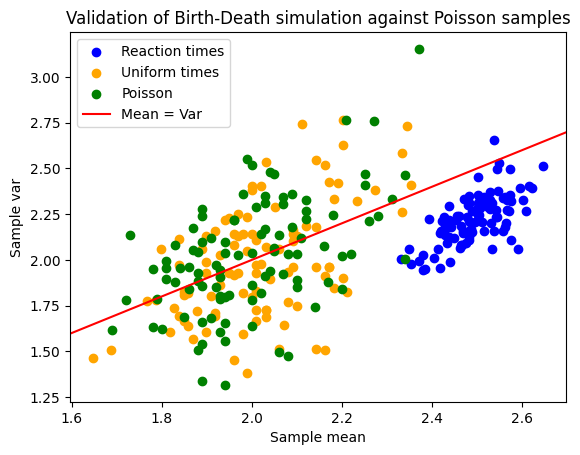

In [30]:
plt.scatter(path_mean, path_var, color="blue", label="Reaction times")
plt.scatter(sampled_mean, sampled_var, color="orange", label="Uniform times")
plt.scatter(poisson_mean, poisson_var, color="green", label="Poisson")
m = rates[0] / rates[1] 
plt.axline([m]*2, [m+0.01]*2, color="red", label="Mean = Var")
plt.xlabel("Sample mean")
plt.ylabel("Sample var")
plt.title("Validation of Birth-Death simulation against Poisson samples")
plt.legend()
plt.show()